In [ ]:
# Ensure figures display in notebook
%matplotlib inline
import matplotlib.pyplot as plt

# Supplementary Notebook: Reproducible figure generation pipeline

This notebook reproduces the finalized paper figures in a **standalone** way using only:

- `pandas`
- `numpy`
- `matplotlib`
- `pathlib`

It does **not** depend on the previous project notebook state.

## Figures included
- Figure 1 — Framework
- Figure 2 — PBMC
- Figure 3 — Norman
- Figure 4 — Replogle
- Figure 5 — Cross-dataset synthesis

## Before running
Update the `PROJECT_DIR` in the next cell so it points to your project root that contains:
- `exports/`
- `artifacts/`


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch, FancyBboxPatch

# =========================
# USER CONFIGURATION
# =========================
PROJECT_DIR = Path("/Users/sally/Desktop/MM-KPNN")  # <-- CHANGE IF NEEDED

EXPORTS_DIR = PROJECT_DIR / "exports"
ARTIFACTS_DIR = PROJECT_DIR / "artifacts"
CROSS_DATASET_DIR = ARTIFACTS_DIR / "cross_dataset_synthesis"
OUTPUT_DIR = ARTIFACTS_DIR / "paper_figures" / "final_figures_standalone"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 160
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.size"] = 10
plt.rcParams["axes.titlesize"] = 11
plt.rcParams["axes.labelsize"] = 10
plt.rcParams["xtick.labelsize"] = 9
plt.rcParams["ytick.labelsize"] = 9
plt.rcParams["legend.fontsize"] = 9
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

DATASET_COLORS = {
    "PBMC": "#4C72B0",
    "Norman": "#DD8452",
    "Replogle": "#55A868",
}

PBMC_STIM_COLORS = {
    "IFN": "#4C72B0",
    "LPS": "#DD8452",
    "PMA": "#55A868",
}

CLASS_COLORS = {
    "TF": "#4C72B0",
    "Chromatin": "#DD8452",
    "Other": "#55A868",
}

def load_tsv(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")
    return pd.read_csv(path, sep="\t")

def save_current_figure(fig, stem):
    png_path = OUTPUT_DIR / f"{stem}.png"
    pdf_path = OUTPUT_DIR / f"{stem}.pdf"
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    print("Saved:")
    print(" -", png_path)
    print(" -", pdf_path)

print("PROJECT_DIR:", PROJECT_DIR)
print("EXPORTS_DIR exists:", EXPORTS_DIR.exists())
print("ARTIFACTS_DIR exists:", ARTIFACTS_DIR.exists())
print("CROSS_DATASET_DIR exists:", CROSS_DATASET_DIR.exists())
print("OUTPUT_DIR:", OUTPUT_DIR)

plt.show()

PROJECT_DIR: /Users/sally/Desktop/MM-KPNN
EXPORTS_DIR exists: True
ARTIFACTS_DIR exists: True
CROSS_DATASET_DIR exists: True
OUTPUT_DIR: /Users/sally/Desktop/MM-KPNN/artifacts/paper_figures/final_figures_standalone


## Load all required inputs

In [2]:
# Figure 2 inputs
fig2_concept_activations = load_tsv(EXPORTS_DIR / "pbmc_mechanistic_concept_activations_by_condition.tsv")
fig2_delta_vs_control = load_tsv(EXPORTS_DIR / "pbmc_mechanistic_concept_activation_delta_vs_control.tsv")
fig2_summary = load_tsv(EXPORTS_DIR / "pbmc_mechanistic_summary_table.tsv")

# Figure 3 inputs
fig3_embedding = load_tsv(ARTIFACTS_DIR / "perturbseq_response_program_pca_embedding.tsv")
fig3_negative_control = load_tsv(ARTIFACTS_DIR / "paper_figures" / "final_figures" / "figure3_inputs" / "figure3_negative_control.tsv")
fig3_mechanistic = load_tsv(CROSS_DATASET_DIR / "norman_synthesis_table.tsv")

# Figure 4 inputs
fig4_metrics = load_tsv(ARTIFACTS_DIR / "paper_figures" / "final_figures" / "figure4_inputs" / "figure4_metrics.tsv")
fig4_classes = load_tsv(ARTIFACTS_DIR / "paper_figures" / "final_figures" / "figure4_inputs" / "figure4_classes.tsv")
fig4_synthesis = load_tsv(ARTIFACTS_DIR / "paper_figures" / "final_figures" / "figure4_inputs" / "figure4_synthesis.tsv")

# Figure 5 inputs
fig5_pbmc = load_tsv(CROSS_DATASET_DIR / "pbmc_synthesis_table.tsv")
fig5_norman = load_tsv(CROSS_DATASET_DIR / "norman_synthesis_table.tsv")
fig5_replogle = load_tsv(CROSS_DATASET_DIR / "replogle_synthesis_table.tsv")

print("All input tables loaded.")

All input tables loaded.


## Figure 1 — Framework

Saved:
 - /Users/sally/Desktop/MM-KPNN/artifacts/paper_figures/final_figures_standalone/Figure1_framework_standalone.png
 - /Users/sally/Desktop/MM-KPNN/artifacts/paper_figures/final_figures_standalone/Figure1_framework_standalone.pdf


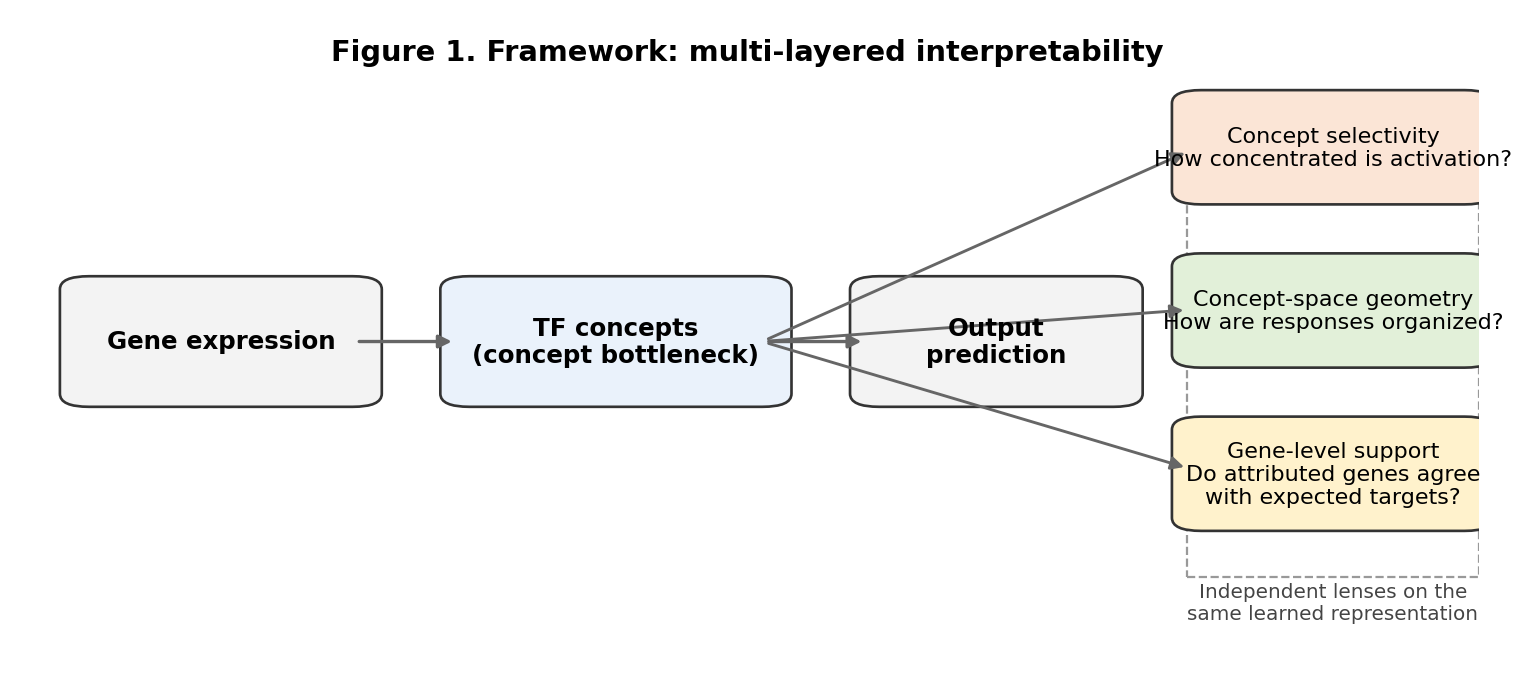

In [3]:
fig, ax = plt.subplots(figsize=(11.8, 5.3))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

def add_box(ax, xy, w, h, text, fc="#F7F7F7", ec="#333333", lw=1.2, fontsize=10, weight="normal"):
    x, y = xy
    patch = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.02,rounding_size=0.02",
        linewidth=lw, edgecolor=ec, facecolor=fc
    )
    ax.add_patch(patch)
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center",
            fontsize=fontsize, fontweight=weight)
    return patch

def add_arrow(ax, start, end, color="#666666", lw=1.5, style="-|>"):
    arr = FancyArrowPatch(
        start, end, arrowstyle=style, mutation_scale=12,
        linewidth=lw, color=color, shrinkA=3, shrinkB=8
    )
    ax.add_patch(arr)
    return arr

ax.text(0.50, 0.965, "Figure 1. Framework: multi-layered interpretability",
        ha="center", va="top", fontsize=13, fontweight="bold")

gene_xy = (0.05, 0.42)
concept_xy = (0.31, 0.42)
output_xy = (0.59, 0.42)

gene_w, gene_h = 0.18, 0.16
concept_w, concept_h = 0.20, 0.16
output_w, output_h = 0.16, 0.16

add_box(ax, gene_xy, gene_w, gene_h, "Gene expression", fc="#F3F3F3", fontsize=11, weight="bold")
add_box(ax, concept_xy, concept_w, concept_h, "TF concepts\n(concept bottleneck)", fc="#EAF2FB", fontsize=11, weight="bold")
add_box(ax, output_xy, output_w, output_h, "Output\nprediction", fc="#F3F3F3", fontsize=11, weight="bold")

add_arrow(ax, (gene_xy[0] + gene_w, gene_xy[1] + gene_h / 2), (concept_xy[0], concept_xy[1] + concept_h / 2))
add_arrow(ax, (concept_xy[0] + concept_w, concept_xy[1] + concept_h / 2), (output_xy[0], output_xy[1] + output_h / 2))

panel_x = 0.81
layer_w, layer_h = 0.18, 0.135
ax.add_patch(Rectangle((panel_x - 0.01, 0.14), layer_w + 0.02, 0.72,
                       fill=False, lw=1.0, ec="#999999", ls="--"))

layers = [
    (0.73, "Concept selectivity\nHow concentrated is activation?", "#FBE5D6"),
    (0.48, "Concept-space geometry\nHow are responses organized?", "#E2F0D9"),
    (0.23, "Gene-level support\nDo attributed genes agree\nwith expected targets?", "#FFF2CC"),
]

for y, label, color in layers:
    add_box(ax, (panel_x, y), layer_w, layer_h, label, fc=color, fontsize=10)

concept_anchor = (concept_xy[0] + concept_w, concept_xy[1] + concept_h / 2)
add_arrow(ax, concept_anchor, (panel_x, 0.80), lw=1.3)
add_arrow(ax, concept_anchor, (panel_x, 0.55), lw=1.3)
add_arrow(ax, concept_anchor, (panel_x, 0.30), lw=1.3)

ax.text(panel_x + layer_w / 2, 0.10,
        "Independent lenses on the\nsame learned representation",
        ha="center", va="center", fontsize=9, color="#444444")

save_current_figure(fig, "Figure1_framework_standalone")
plt.show()
plt.close(fig)

## Figure 2 — PBMC

Saved:
 - /Users/sally/Desktop/MM-KPNN/artifacts/paper_figures/final_figures_standalone/Figure2_PBMC_standalone.png
 - /Users/sally/Desktop/MM-KPNN/artifacts/paper_figures/final_figures_standalone/Figure2_PBMC_standalone.pdf


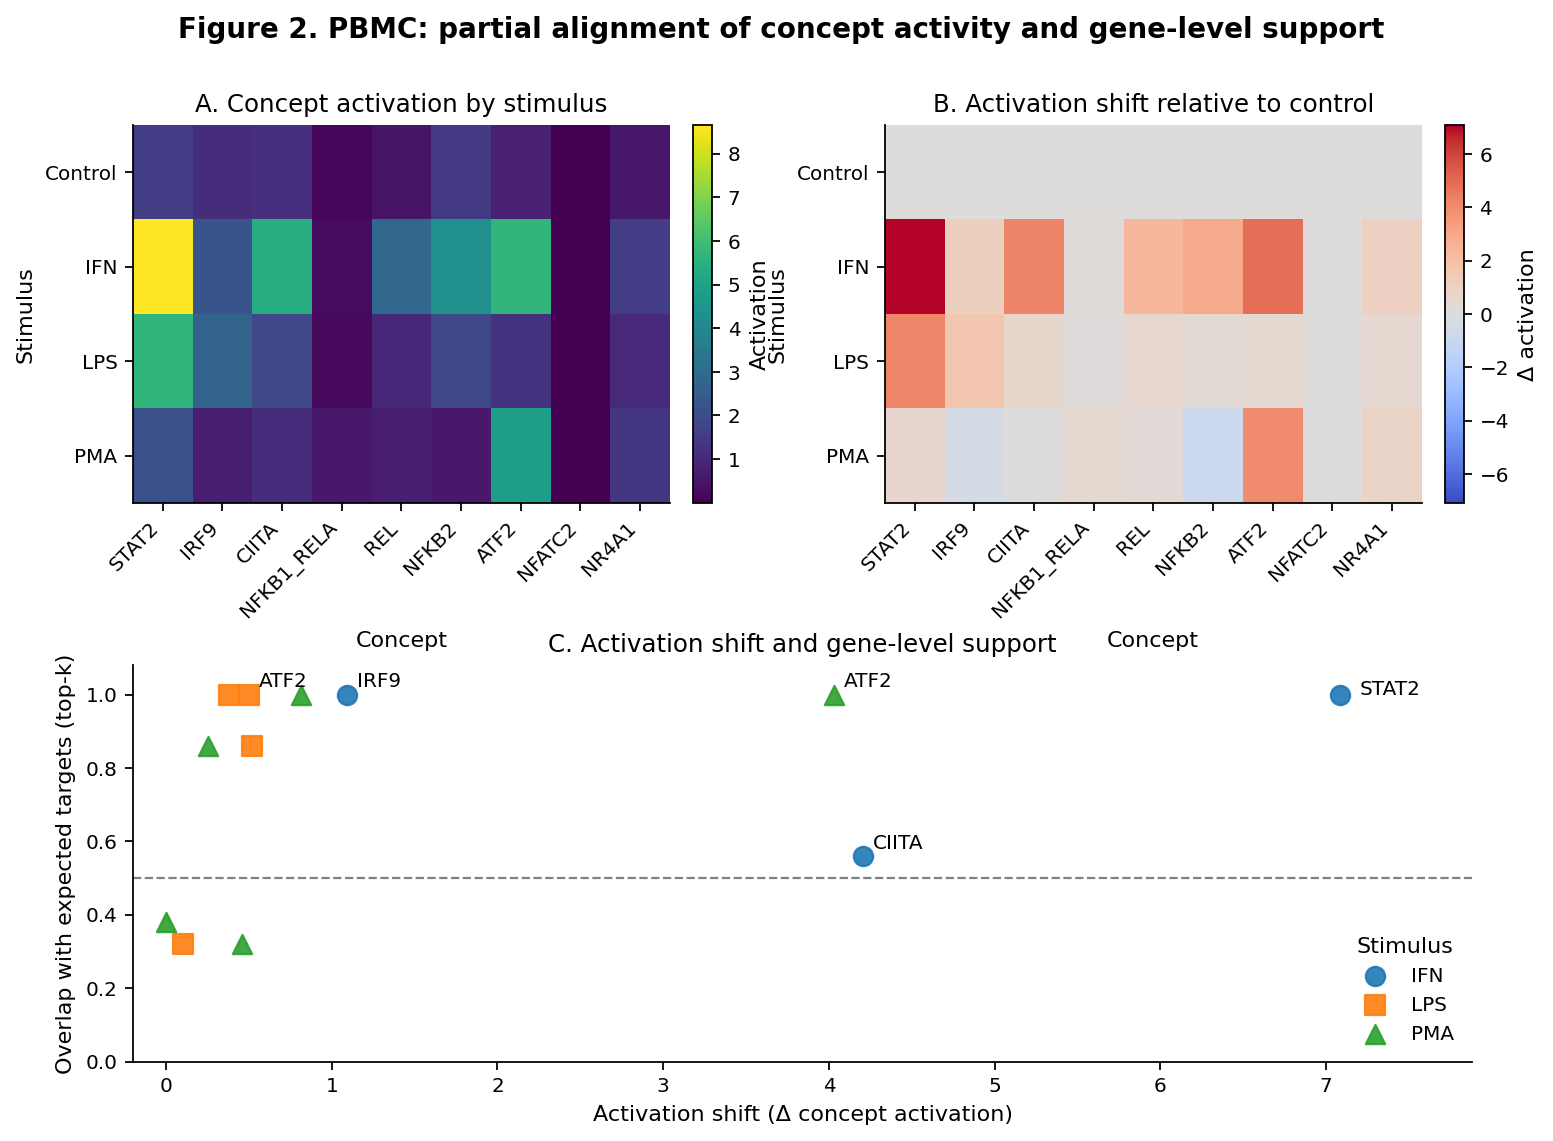

In [4]:
pbmc_act = fig2_concept_activations.copy()
pbmc_delta = fig2_delta_vs_control.copy()
pbmc_sum = fig2_summary.copy()

stimulus_order = ["Control", "IFN", "LPS", "PMA"]
summary_stimulus_order = ["IFN", "LPS", "PMA"]
concept_order = [c for c in pbmc_act.columns if c != "stimulus"]

pbmc_act["stimulus"] = pd.Categorical(pbmc_act["stimulus"], categories=stimulus_order, ordered=True)
pbmc_delta["stimulus"] = pd.Categorical(pbmc_delta["stimulus"], categories=stimulus_order, ordered=True)
pbmc_sum["stimulus"] = pd.Categorical(pbmc_sum["stimulus"], categories=summary_stimulus_order, ordered=True)

pbmc_act = pbmc_act.sort_values("stimulus").reset_index(drop=True)
pbmc_delta = pbmc_delta.sort_values("stimulus").reset_index(drop=True)
pbmc_sum = pbmc_sum.sort_values(["stimulus", "delta_activation_vs_control"], ascending=[True, False]).reset_index(drop=True)

act_mat = pbmc_act.set_index("stimulus")[concept_order]
delta_mat = pbmc_delta.set_index("stimulus")[concept_order]
scatter_df = pbmc_sum.copy()

fig = plt.figure(figsize=(10.8, 7.6))
gs = fig.add_gridspec(2, 2, height_ratios=[1.0, 1.05], hspace=0.42, wspace=0.28)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])

fig.suptitle(
    "Figure 2. PBMC: partial alignment of concept activity and gene-level support",
    fontsize=12.5, fontweight="bold", y=0.97
)

im1 = ax1.imshow(act_mat.values, aspect="auto")
ax1.set_title("A. Concept activation by stimulus", fontsize=11)
ax1.set_xlabel("Concept")
ax1.set_ylabel("Stimulus")
ax1.set_xticks(np.arange(len(concept_order)))
ax1.set_xticklabels(concept_order, rotation=45, ha="right")
ax1.set_yticks(np.arange(len(act_mat.index)))
ax1.set_yticklabels(act_mat.index.tolist())
cbar1 = fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
cbar1.set_label("Activation")

delta_vals = delta_mat.values.astype(float)
vmax = np.nanmax(np.abs(delta_vals))
im2 = ax2.imshow(delta_vals, aspect="auto", vmin=-vmax, vmax=vmax, cmap="coolwarm")
ax2.set_title("B. Activation shift relative to control", fontsize=11)
ax2.set_xlabel("Concept")
ax2.set_ylabel("Stimulus")
ax2.set_xticks(np.arange(len(concept_order)))
ax2.set_xticklabels(concept_order, rotation=45, ha="right")
ax2.set_yticks(np.arange(len(delta_mat.index)))
ax2.set_yticklabels(delta_mat.index.tolist())
cbar2 = fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
cbar2.set_label("Δ activation")

markers = {"IFN": "o", "LPS": "s", "PMA": "^"}
for stim in summary_stimulus_order:
    sub = scatter_df[scatter_df["stimulus"] == stim]
    ax3.scatter(
        sub["delta_activation_vs_control"],
        sub["overlap_fraction_topk"],
        s=75,
        marker=markers[stim],
        label=stim,
        alpha=0.9
    )

label_offsets = {
    "STAT2": (0.12, 0.00),
    "CIITA": (0.06, 0.02),
    "ATF2": (0.06, 0.02),
    "IRF9": (0.06, 0.02),
}
for _, row in scatter_df.iterrows():
    concept = row["concept"]
    if concept not in label_offsets:
        continue
    dx, dy = label_offsets[concept]
    ax3.text(row["delta_activation_vs_control"] + dx,
             row["overlap_fraction_topk"] + dy,
             concept, fontsize=9)

ax3.axhline(0.5, linestyle="--", linewidth=1.0, color="gray")
ax3.set_title("C. Activation shift and gene-level support", fontsize=11)
ax3.set_xlabel("Activation shift (Δ concept activation)")
ax3.set_ylabel("Overlap with expected targets (top-k)")
ax3.set_ylim(0, 1.08)

xmin = float(scatter_df["delta_activation_vs_control"].min()) - 0.2
xmax = float(scatter_df["delta_activation_vs_control"].max()) + 0.8
ax3.set_xlim(xmin, xmax)

ax3.legend(title="Stimulus", frameon=False, loc="lower right")

save_current_figure(fig, "Figure2_PBMC_standalone")
plt.show()
plt.close(fig)

## Figure 3 — Norman

Saved:
 - /Users/sally/Desktop/MM-KPNN/artifacts/paper_figures/final_figures_standalone/Figure3_Norman_standalone.png
 - /Users/sally/Desktop/MM-KPNN/artifacts/paper_figures/final_figures_standalone/Figure3_Norman_standalone.pdf


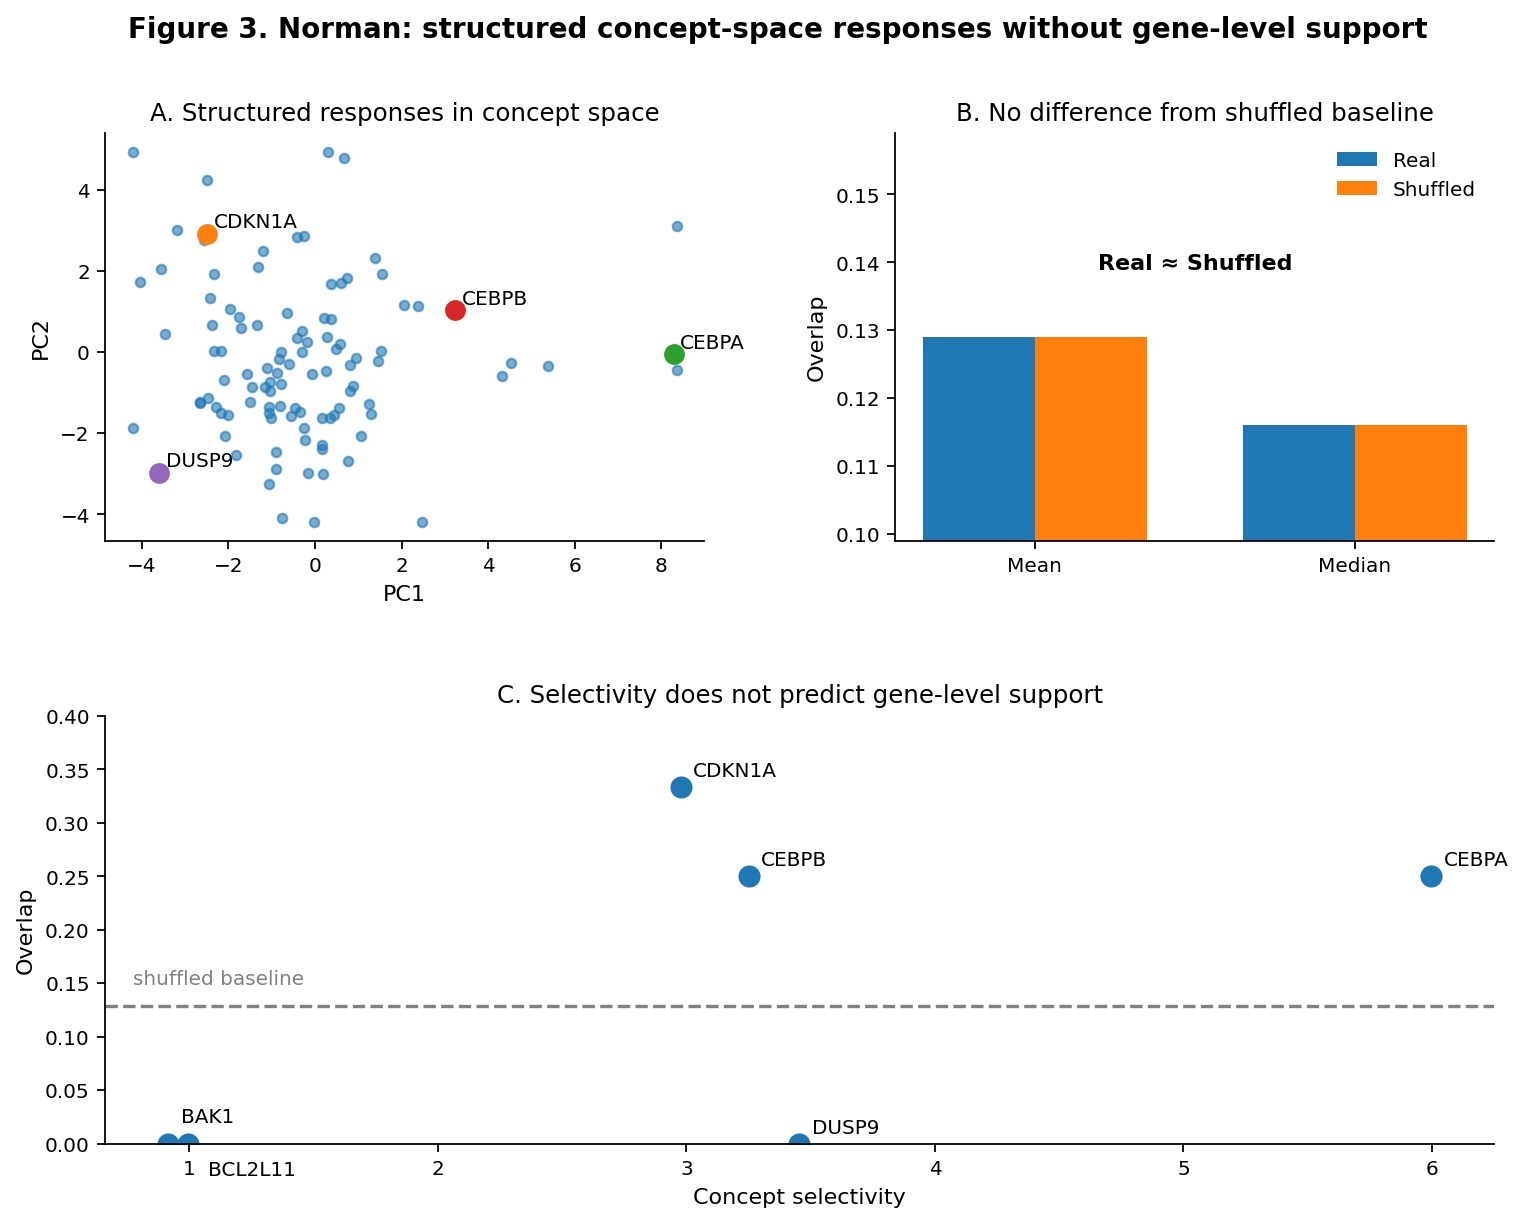

In [5]:
embedding = fig3_embedding.copy()
neg = fig3_negative_control.copy()
mech = fig3_mechanistic.copy()

fig = plt.figure(figsize=(11.2, 8.2))
gs = fig.add_gridspec(2, 2, height_ratios=[1.0, 1.05], hspace=0.42, wspace=0.32)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])

fig.suptitle(
    "Figure 3. Norman: structured concept-space responses without gene-level support",
    fontsize=12.5, fontweight="bold", y=0.97
)

pc1_lo, pc1_hi = np.percentile(embedding["PC1"], [1, 99])
pc2_lo, pc2_hi = np.percentile(embedding["PC2"], [1, 99])

pc1 = embedding["PC1"].clip(pc1_lo, pc1_hi)
pc2 = embedding["PC2"].clip(pc2_lo, pc2_hi)

ax1.scatter(pc1, pc2, s=18, alpha=0.6)

highlight = ["CDKN1A", "CEBPA", "CEBPB", "DUSP9"]
colors = ["tab:orange", "tab:green", "tab:red", "tab:purple"]

for p, c in zip(highlight, colors):
    sub = embedding[embedding["perturbation"] == p]
    if len(sub) == 0:
        continue
    x = float(sub["PC1"].iloc[0])
    y = float(sub["PC2"].iloc[0])
    ax1.scatter([x], [y], s=70, color=c)
    ax1.text(x + 0.15, y + 0.15, p, fontsize=9)

ax1.set_title("A. Structured responses in concept space", fontsize=11)
ax1.set_xlabel("PC1")
ax1.set_ylabel("PC2")

real_mean = float(neg["real_mean_top3_frac"].iloc[0])
shuf_mean = float(neg["shuffled_mean_top3_frac"].iloc[0])
real_med = float(neg["real_median_top3_frac"].iloc[0])
shuf_med = float(neg["shuffled_median_top3_frac"].iloc[0])

x = np.arange(2)
width = 0.35
ax2.bar(x - width/2, [real_mean, real_med], width, label="Real")
ax2.bar(x + width/2, [shuf_mean, shuf_med], width, label="Shuffled")

ax2.set_xticks(x)
ax2.set_xticklabels(["Mean", "Median"])
ax2.set_ylabel("Overlap")
ax2.set_title("B. No difference from shuffled baseline", fontsize=11)
ax2.set_ylim(real_mean - 0.03, real_mean + 0.03)
y_text = max(real_mean, shuf_mean) + 0.01
ax2.text(0.5, y_text, "Real ≈ Shuffled", ha="center", fontsize=10, fontweight="bold")
ax2.legend(frameon=False)

ax3.scatter(mech["concept_selectivity"], mech["overlap_fraction_topk"], s=80)

for _, row in mech.iterrows():
    x = row["concept_selectivity"]
    y = row["overlap_fraction_topk"]
    if row["entity"] == "BACH1":
        dx, dy = 0.05, 0.02
    elif row["entity"] == "BCL2L11":
        dx, dy = 0.08, -0.03
    elif row["entity"] == "BAK1":
        dx, dy = 0.05, 0.02
    else:
        dx, dy = 0.05, 0.01
    ax3.text(x + dx, y + dy, row["entity"], fontsize=9)

threshold = float(neg["real_mean_top3_frac"].iloc[0])
ax3.axhline(threshold, linestyle="--", color="gray")
ax3.text(0.02, threshold + 0.02, "shuffled baseline",
         transform=ax3.get_yaxis_transform(), fontsize=9, color="gray")

ax3.set_title("C. Selectivity does not predict gene-level support", fontsize=11)
ax3.set_xlabel("Concept selectivity")
ax3.set_ylabel("Overlap")
ax3.set_ylim(0, 0.4)

save_current_figure(fig, "Figure3_Norman_standalone")
plt.show()
plt.close(fig)

## Figure 4 — Replogle

Saved:
 - /Users/sally/Desktop/MM-KPNN/artifacts/paper_figures/final_figures_standalone/Figure4_Replogle_standalone.png
 - /Users/sally/Desktop/MM-KPNN/artifacts/paper_figures/final_figures_standalone/Figure4_Replogle_standalone.pdf


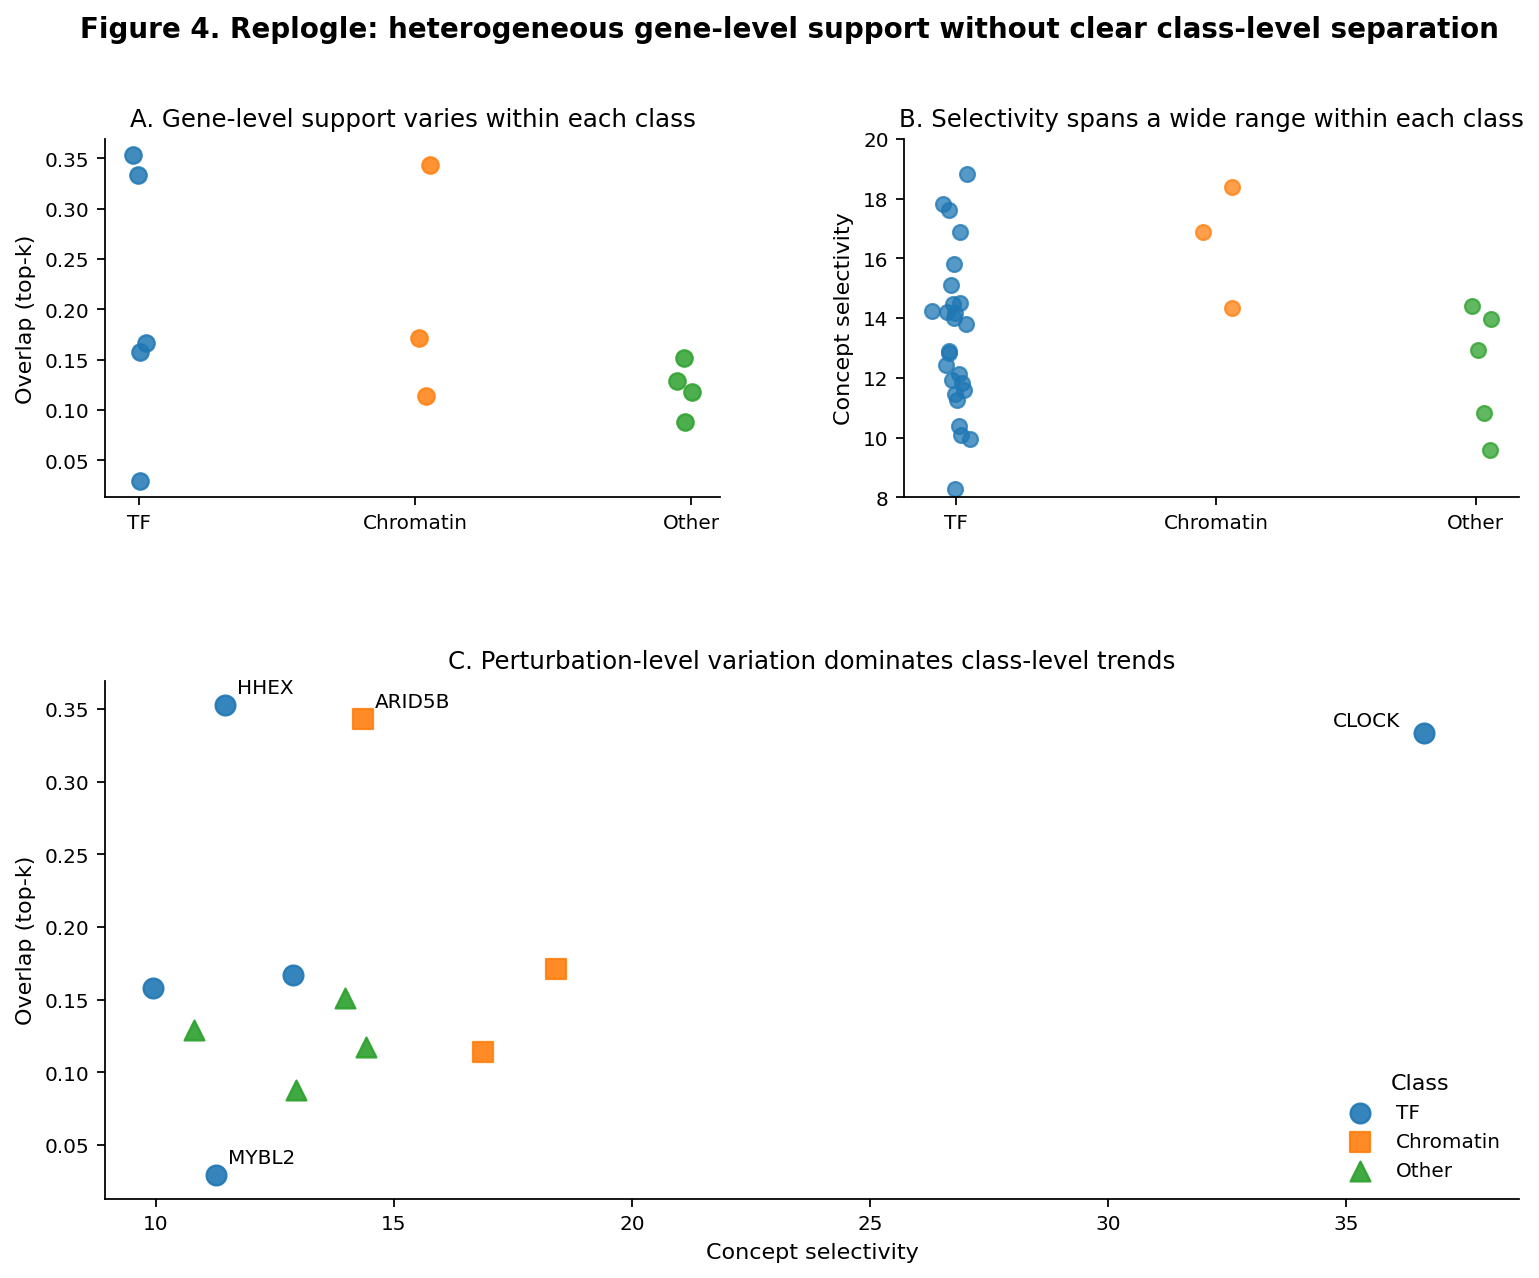

In [6]:
metrics = fig4_metrics.copy()
classes = fig4_classes.copy()
synth = fig4_synthesis.copy()

cls = classes.copy()
cls["regulator_class"] = cls["regulator_class"].replace({
    "chromatin": "Chromatin",
    "cofactor": "Other",
    "other": "Other",
    "tf": "TF",
    "TF": "TF"
})

sel_df = metrics.merge(cls.rename(columns={"gene": "perturbation"}), on="perturbation", how="left")
syn_df = synth.merge(cls.rename(columns={"gene": "entity"}), on="entity", how="left")

for df in [sel_df, syn_df]:
    df["regulator_class"] = df["regulator_class"].fillna("Other")
    df["regulator_class"] = pd.Categorical(df["regulator_class"],
                                           categories=["TF", "Chromatin", "Other"],
                                           ordered=True)

panelB = sel_df.dropna(subset=["regulator_class", "concept_selectivity"]).copy()
panelC = syn_df.dropna(subset=["regulator_class", "concept_selectivity", "overlap_fraction_topk"]).copy()

fig = plt.figure(figsize=(11.4, 8.6))
gs = fig.add_gridspec(2, 2, height_ratios=[0.9, 1.3], hspace=0.42, wspace=0.30)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])

fig.suptitle(
    "Figure 4. Replogle: heterogeneous gene-level support without clear class-level separation",
    fontsize=12.5, fontweight="bold", y=0.97
)

class_order = ["TF", "Chromatin", "Other"]
rng = np.random.default_rng(0)

for i, c in enumerate(class_order, start=1):
    vals = panelC.loc[panelC["regulator_class"] == c, "overlap_fraction_topk"].values
    jitter = rng.normal(0, 0.04, size=len(vals))
    ax1.scatter(np.full(len(vals), i) + jitter, vals, s=55, alpha=0.85)

ax1.set_xticks([1, 2, 3])
ax1.set_xticklabels(class_order)
ax1.set_ylabel("Overlap (top-k)")
ax1.set_title("A. Gene-level support varies within each class", fontsize=11)

for i, c in enumerate(class_order, start=1):
    vals = panelB.loc[panelB["regulator_class"] == c, "concept_selectivity"].values
    jitter = rng.normal(0, 0.04, size=len(vals))
    ax2.scatter(np.full(len(vals), i) + jitter, vals, s=45, alpha=0.75)

ax2.set_xticks([1, 2, 3])
ax2.set_xticklabels(class_order)
ax2.set_ylabel("Concept selectivity")
ax2.set_title("B. Selectivity spans a wide range within each class", fontsize=11)
ax2.set_ylim(8, 20)

markers = {"TF": "o", "Chromatin": "s", "Other": "^"}
for c in class_order:
    sub = panelC[panelC["regulator_class"] == c]
    ax3.scatter(
        sub["concept_selectivity"],
        sub["overlap_fraction_topk"],
        s=80,
        marker=markers[c],
        label=c,
        alpha=0.9
    )

to_label = {"CLOCK", "HHEX", "ARID5B", "MYBL2"}
for _, row in panelC.iterrows():
    if row["entity"] not in to_label:
        continue
    x = row["concept_selectivity"]
    y = row["overlap_fraction_topk"]
    if row["entity"] == "CLOCK":
        ax3.text(x - 0.5, y + 0.005, row["entity"], fontsize=9, ha="right")
    else:
        ax3.text(x + 0.25, y + 0.008, row["entity"], fontsize=9)

ax3.set_title("C. Perturbation-level variation dominates class-level trends", fontsize=11)
ax3.set_xlabel("Concept selectivity")
ax3.set_ylabel("Overlap (top-k)")
xmin = panelC["concept_selectivity"].min() - 1
xmax = panelC["concept_selectivity"].max() + 2
ax3.set_xlim(xmin, xmax)
ax3.legend(title="Class", frameon=False, loc="lower right")

save_current_figure(fig, "Figure4_Replogle_standalone")
plt.show()
plt.close(fig)

## Figure 5 — Cross-dataset synthesis

Saved:
 - /Users/sally/Desktop/MM-KPNN/artifacts/paper_figures/final_figures_standalone/Figure5_cross_dataset_standalone.png
 - /Users/sally/Desktop/MM-KPNN/artifacts/paper_figures/final_figures_standalone/Figure5_cross_dataset_standalone.pdf


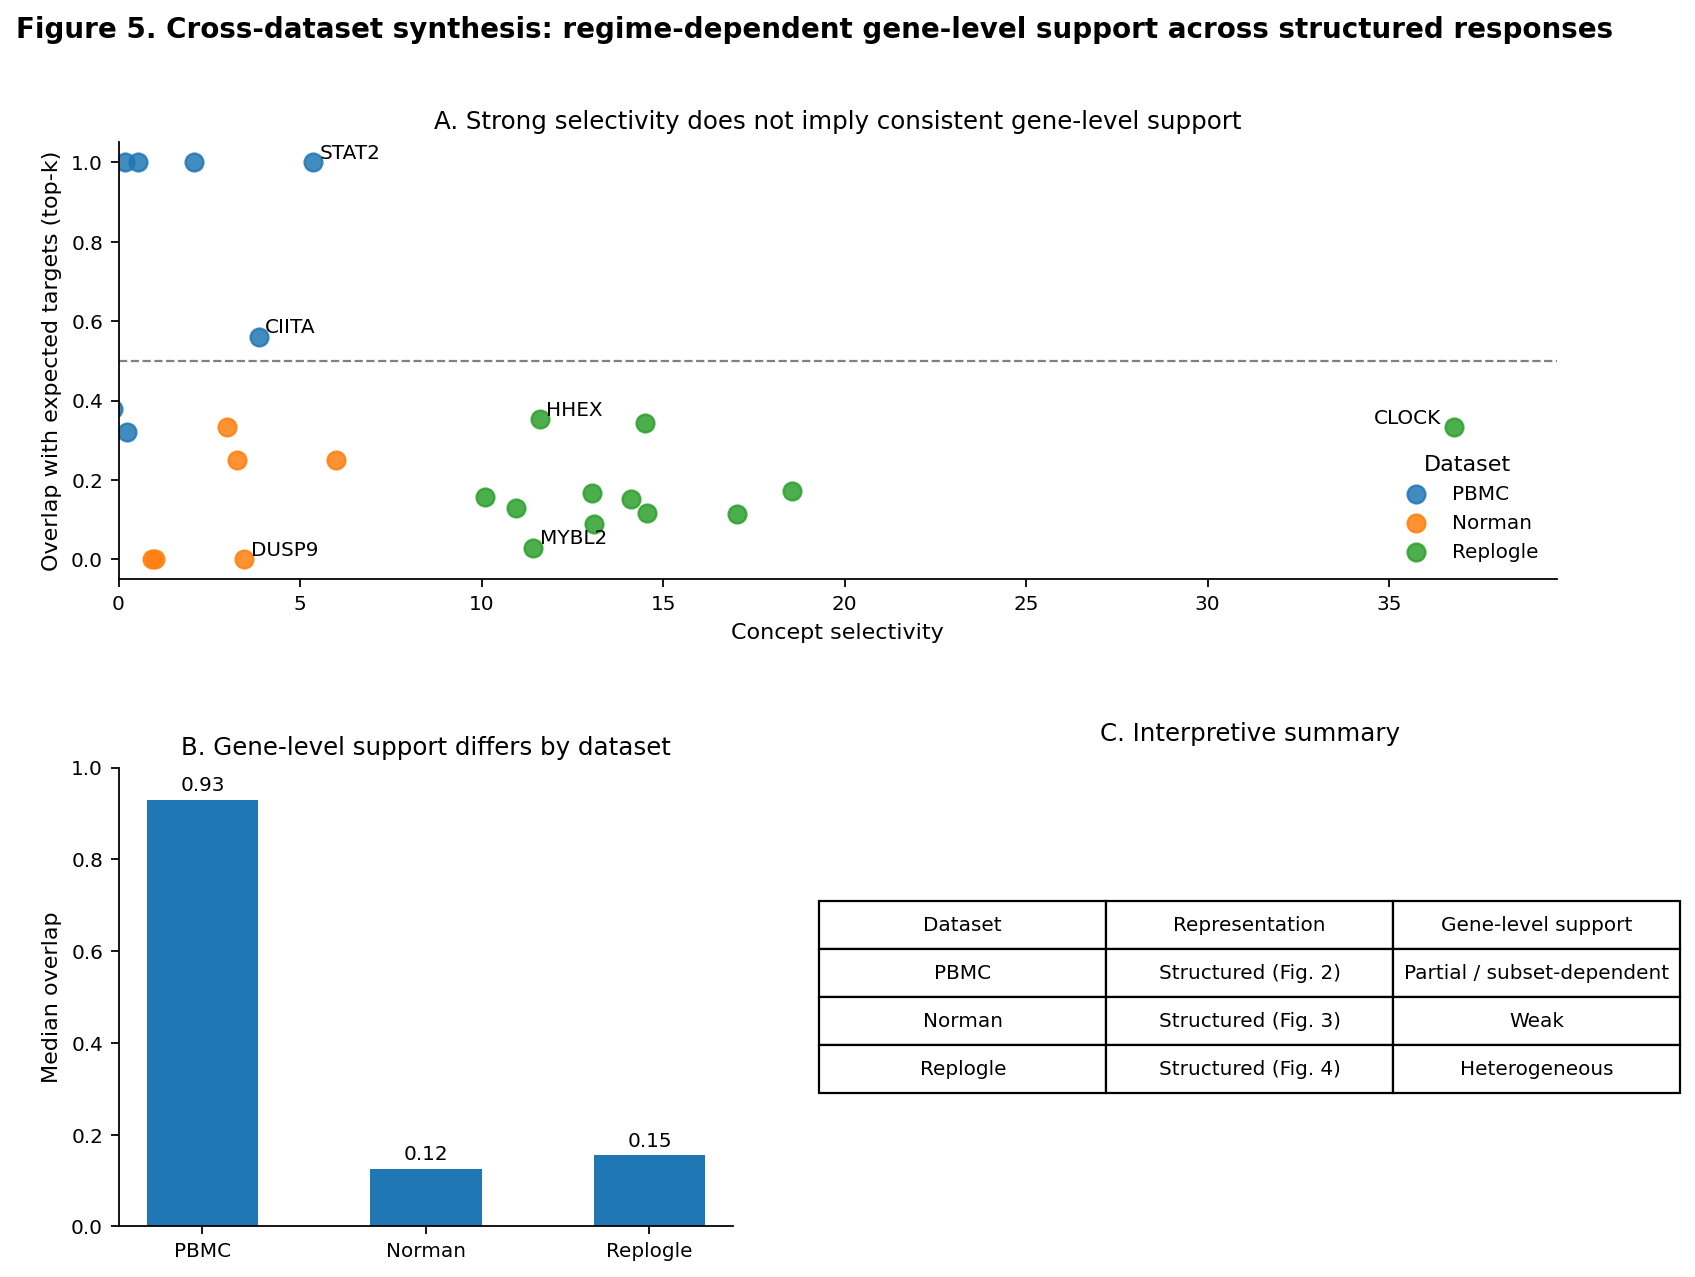

In [7]:
pbmc_plot = fig5_pbmc[["dataset", "entity", "concept", "concept_selectivity", "overlap_fraction_topk"]].copy()
norman_plot = fig5_norman[["dataset", "entity", "concept", "concept_selectivity", "overlap_fraction_topk"]].copy()
replogle_plot = fig5_replogle[["dataset", "entity", "concept", "concept_selectivity", "overlap_fraction_topk"]].copy()

all_df = pd.concat([pbmc_plot, norman_plot, replogle_plot], ignore_index=True)
dataset_order = ["PBMC", "Norman", "Replogle"]
all_df["dataset"] = pd.Categorical(all_df["dataset"], categories=dataset_order, ordered=True)

summary_df = (
    all_df.groupby("dataset", observed=False)
    .agg(
        mean_selectivity=("concept_selectivity", "mean"),
        median_overlap=("overlap_fraction_topk", "median"),
        n=("entity", "count")
    )
    .reset_index()
)

fig = plt.figure(figsize=(11.6, 8.8))
gs = fig.add_gridspec(2, 2, height_ratios=[1.0, 1.05], hspace=0.42, wspace=0.34)

ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

fig.suptitle(
    "Figure 5. Cross-dataset synthesis: regime-dependent gene-level support across structured responses",
    fontsize=12.5, fontweight="bold", y=0.97
)

dataset_offsets = {"PBMC": -0.15, "Norman": 0.0, "Replogle": 0.15}
for ds in dataset_order:
    sub = all_df[all_df["dataset"] == ds].copy()
    xvals = sub["concept_selectivity"].astype(float) + dataset_offsets[ds]
    ax1.scatter(xvals, sub["overlap_fraction_topk"], s=65, label=ds, alpha=0.85)

label_points = {"STAT2", "CIITA", "DUSP9", "CLOCK", "HHEX", "MYBL2"}
for _, row in all_df.iterrows():
    concept_label = str(row["concept"]) if pd.notna(row["concept"]) else ""
    entity_label = str(row["entity"])
    if concept_label not in label_points and entity_label not in label_points:
        continue
    label = concept_label if concept_label in label_points else entity_label
    x = float(row["concept_selectivity"]) + dataset_offsets[str(row["dataset"])]
    y = float(row["overlap_fraction_topk"])
    if label == "CLOCK":
        ax1.text(x - 0.35, y + 0.01, label, fontsize=9, ha="right")
    else:
        ax1.text(x + 0.18, y + 0.01, label, fontsize=9)

ax1.axhline(0.5, linestyle="--", linewidth=1.0, color="gray")
ax1.set_title("A. Strong selectivity does not imply consistent gene-level support", fontsize=11)
ax1.set_xlabel("Concept selectivity")
ax1.set_ylabel("Overlap with expected targets (top-k)")
ax1.legend(title="Dataset", frameon=False, loc="lower right")
ax1.set_xlim(0, all_df["concept_selectivity"].max() + 3)

x = np.arange(len(summary_df))
ax2.bar(x, summary_df["median_overlap"], width=0.5)
ax2.set_xticks(x)
ax2.set_xticklabels(summary_df["dataset"].astype(str).tolist())
ax2.set_title("B. Gene-level support differs by dataset", fontsize=11)
ax2.set_ylabel("Median overlap")
ax2.set_ylim(0, 1.0)
for i, row in summary_df.iterrows():
    ax2.text(i, row["median_overlap"] + 0.02, f"{row['median_overlap']:.2f}", ha="center", fontsize=9)

ax3.axis("off")
table_text = [
    ["PBMC",     "Structured (Fig. 2)", "Partial / subset-dependent"],
    ["Norman",   "Structured (Fig. 3)", "Weak"],
    ["Replogle", "Structured (Fig. 4)", "Heterogeneous"],
]
tbl = ax3.table(
    cellText=table_text,
    colLabels=["Dataset", "Representation", "Gene-level support"],
    loc="center",
    cellLoc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.4, 1.8)
ax3.set_title("C. Interpretive summary", fontsize=11, pad=12)

save_current_figure(fig, "Figure5_cross_dataset_standalone")
plt.show()
plt.close(fig)